# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import autograd.numpy as anp
from autograd import grad

# Create Schwarzschild Metric

In [4]:
def H_schwarzschild(x, M=1.0):
    t, r, th, ph, p_t, p_r, p_th, p_ph = x
    f = 1.0 - 2.0*M/r

    # Canonical momentum 4-vector (covariant components)
    p = anp.array([p_t, p_r, p_th, p_ph])

    # Schwarzschild metric g_{μν}
    g = anp.array([
        [-f,         0.0,      0.0,                     0.0],
        [ 0.0,     1.0/f,      0.0,                     0.0],
        [ 0.0,       0.0,     r**2,                     0.0],
        [ 0.0,       0.0,      0.0,   r**2 * anp.sin(th)**2]
    ])

    inv_g = anp.linalg.inv(g)          # g^{μν}
    H = 0.5 * (p.T @ inv_g @ p)
    return H

# Define Poisson Matrix

In [9]:
def make_poisson_J():
    Z = np.zeros((4, 4))
    I = np.eye(4)
    J = np.block([[Z, I],
                  [-I, Z]])
    return J

J = make_poisson_J()

# Define $\nabla E$

In [10]:
gradH = grad(lambda x, M: H_schwarzschild(x, M))

# Equations of Motion

In [11]:
def rhs_coordinate_time(t, x, M=1.0):
    gH = np.asarray(gradH(x, M), dtype=float)      # shape (8,)
    du_dtau = J @ gH                               # shape (8,)

    dH_dpt = gH[4]
    dtaudt = 1.0 / dH_dpt

    du = du_dtau * dtaudt

    # Julia forces coordinate time variable to be the independent variable
    du[0] = 1.0
    return du

# Parameters

In [12]:
# ----------------------------
# Example: integrate and plot
# ----------------------------
M = 1.0
R = 11.0*M
BH_Kick = 0.2

# Initial Conditions

In [13]:
def Angular_Momentum(r, M):
  return np.sqrt((M*r)/(1-(3*M)/r))

def Elliptical_Orbit_Energy(r, M, p_r, p_phi):
  H0 = -0.5
  f = 1 - (2*M/r)
  E2 = -(f) * (2*H0 - (p_phi**2)/(r**2) - f*(p_r**2))
  return np.sqrt(E2)

L = Angular_Momentum(R, M)
E = Elliptical_Orbit_Energy(R, M, BH_Kick, L)

# Integrate Equations to get Geodesic

In [14]:
x0 = np.array([0.0, R, np.pi/2, 0.0, -E, BH_Kick, 0.0, L])

t_span = (0.0, 2000.0)
t_eval = np.linspace(t_span[0], t_span[1], 4000)
sol = solve_ivp(lambda t, x: rhs_coordinate_time(t, x, M),
                t_span, x0, t_eval=t_eval, rtol=1e-9, atol=1e-12)

t_arr  = sol.y[0]
r_arr  = sol.y[1]
ph_arr = sol.y[3]

x = r_arr*np.cos(ph_arr)
y = r_arr*np.sin(ph_arr)

# Plot Schwarzschild Geodesics!

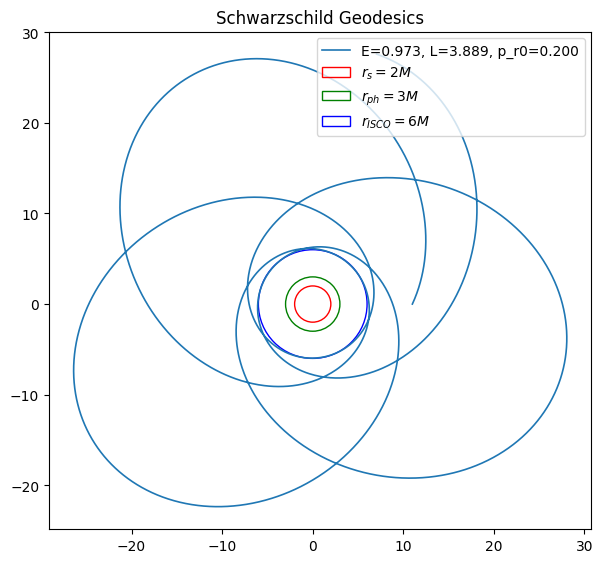

In [15]:
fig, ax = plt.subplots(figsize=(7,7))
ax.plot(x, y, lw=1.2, label=f"E={E:.3f}, L={L:.3f}, p_r0={BH_Kick:.3f}")
ax.add_patch(plt.Circle((0,0), 2*M, color='r', fill=False, label=r"$r_s=2M$"))
ax.add_patch(plt.Circle((0,0), 3*M, color='g', fill=False, label=r"$r_{ph}=3M$"))
ax.add_patch(plt.Circle((0,0), 6*M, color='b', fill=False, label=r"$r_{ISCO}=6M$"))
ax.set_aspect('equal')
ax.legend(loc="upper right")
ax.set_title("Schwarzschild Geodesics")
plt.show()